<a href="https://colab.research.google.com/github/vrohithklh/ML_PRACTICALS/blob/main/ML_Experiment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import files

In [34]:
uploaded = files.upload()  # upload placement_predict_50k_Dataset.csv

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset (2).csv


In [35]:
import pandas as pd

In [36]:
import numpy as np

In [37]:
import matplotlib.pyplot as plt

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
from sklearn.compose import ColumnTransformer

In [40]:
from sklearn.pipeline import Pipeline

In [41]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [42]:
from sklearn.impute import SimpleImputer

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [45]:
pd.set_option('display.max_columns', None)

In [46]:
df = pd.read_csv('placement_predict_50k Dataset.csv')

In [47]:
df.head()

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,1,2,NaN,2,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,0,1,0.0,1,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,1,3,1.0,1,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,1,2,1.0,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,2,3,NaN,4,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [48]:
print(df.shape)

(50000, 32)


In [49]:
df.head()

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,1,2,NaN,2,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,0,1,0.0,1,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,1,3,1.0,1,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,1,2,1.0,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,2,3,NaN,4,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [50]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
dtype: int64


In [51]:
print(df['PlacementStatus'].value_counts())

PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [52]:
print(df['CGPA_Tier'].value_counts())

CGPA_Tier
Low     16733
High    16681
Mid     16586
Name: count, dtype: int64


In [53]:
drop_common = ['StudentID', 'IsAnomaly', 'Salary Package']

In [54]:
categorical_cols = [
    'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation',
    'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular'
]

In [55]:
numeric_cols = [
    'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5',
    'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent',
    'Internships', 'Projects', 'Workshops', 'Certifications',
    'Publications', 'AptitudeTestScore', 'SoftSkillsRating',
    'CodingTestScore', 'MockInterviewScore'
]

In [56]:
print(len(categorical_cols), 'categorical |', len(numeric_cols), 'numeric')

8 categorical | 19 numeric


In [57]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [58]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [59]:
def evaluate_classifier(model, X_test, y_test, class_names=None, average='binary'):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=average, zero_division=0)
    rec = recall_score(y_test, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_test, y_pred, average=average, zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    if average == 'binary' and hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        print(f"ROC-AUC  : {auc:.4f}")

        plt.figure(figsize=(5, 5))
        plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()
    ticks = class_names if class_names is not None else np.unique(y_test)
    plt.xticks(range(len(ticks)), ticks, rotation=45)
    plt.yticks(range(len(ticks)), ticks)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

In [60]:
X1 = df[numeric_cols + categorical_cols]

In [61]:
y1 = df['PlacementStatus']

In [62]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

In [63]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

placement_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [64]:
placement_model.fit(X1_train, y1_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SGPA_Sem1', 'SGPA_Sem2',
                                                   'SGPA_Sem3', 'SGPA_Sem4',
                                                   'SGPA_Sem5', 'SGPA_Sem6',
                                                   'SGPA_Sem7', 'SGPA_Sem8',
                                                   'CGPA', 'AttendancePercent',
                                                   'Internships', 'Projects',
                                                   'Workshops',
                                                   'Certifications',
                                                   'Publicati...
                                                   'CodingTestScore',
                                                   'MockInterviewScore']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'City',
                                                   'CollegeTier', 'Stream',
                                                   'Specialisation', 'Hostel',
                                                   'HistoryOfBacklogs',
                                                   'ExtraCurricular'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Accuracy : 0.9201
Precision: 0.9259
Recall   : 0.9548
F1-score : 0.9401
ROC-AUC  : 0.9793


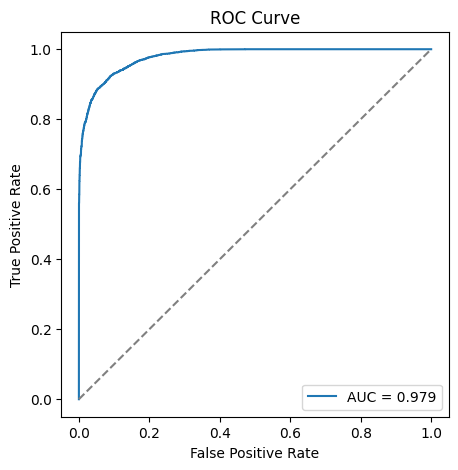

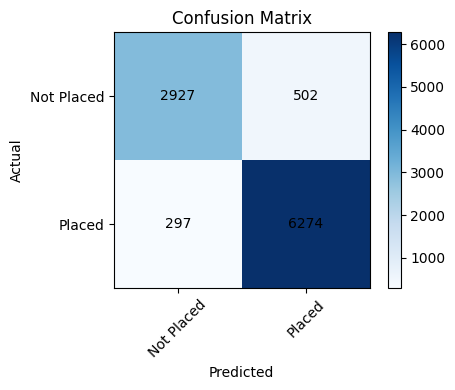


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88      3429
           1       0.93      0.95      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000



In [65]:
results_placement = evaluate_classifier(
    placement_model, X1_test, y1_test,
    class_names=['Not Placed', 'Placed'], average='binary'
)


In [66]:
def get_feature_names(preprocessor, numeric_cols, categorical_cols):
  ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
  cat_names = ohe.get_feature_names_out(categorical_cols)
  return list(numeric_cols) + list(cat_names)


In [67]:
feature_names_1 = get_feature_names(
    placement_model.named_steps['preprocessor'], numeric_cols, categorical_cols
)

In [68]:
coefs_1 = placement_model.named_steps['classifier'].coef_[0]

In [69]:
coef_df_1 = pd.DataFrame({'feature': feature_names_1, 'coefficient': coefs_1})

In [70]:
coef_df_1 = coef_df_1.reindex(coef_df_1.coefficient.abs().sort_values(ascending=False).index)

In [71]:
plt.figure(figsize=(9, max(6, len(coef_df_1) * 0.25)))

<Figure size 900x1050 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

In [72]:
colors = ['#2E7D32' if c > 0 else '#C62828' for c in coef_df_1['coefficient']]

<BarContainer object of 42 artists>

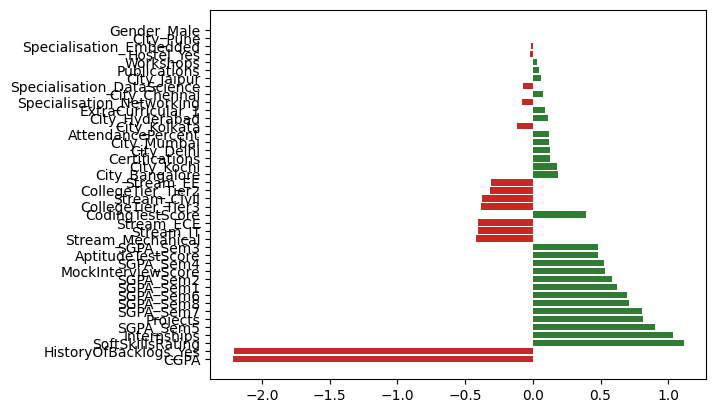

In [73]:
plt.barh(coef_df_1['feature'], coef_df_1['coefficient'], color=colors)

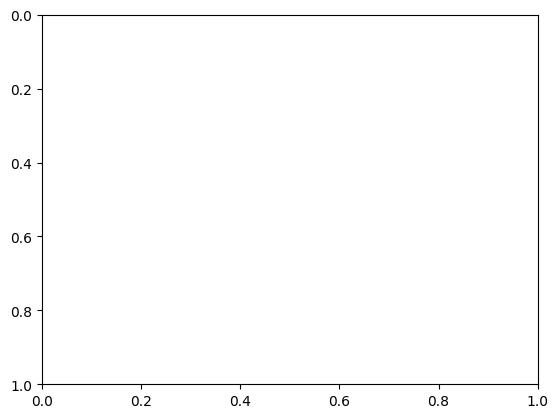

In [74]:
plt.gca().invert_yaxis()

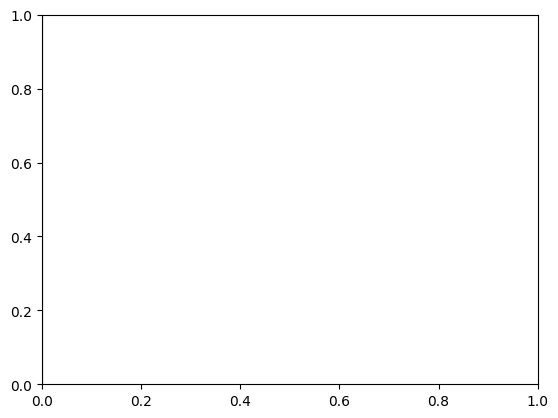

In [75]:
plt.axvline(0, color='black', linewidth=0.8)

Text(0.5, 0, 'Coefficient (log-odds impact)')

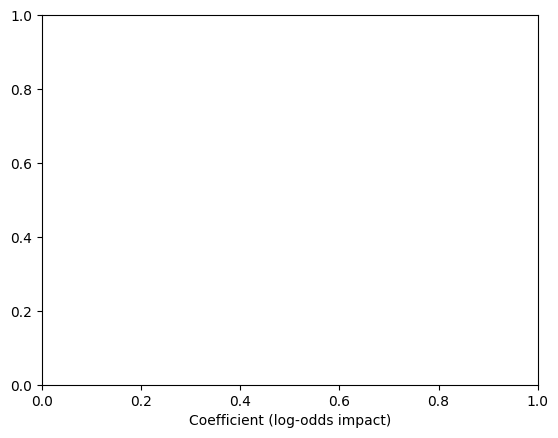

In [76]:
plt.xlabel('Coefficient (log-odds impact)')

Text(0.5, 1.0, 'PlacementStatus Logistic Regression — Coefficients')

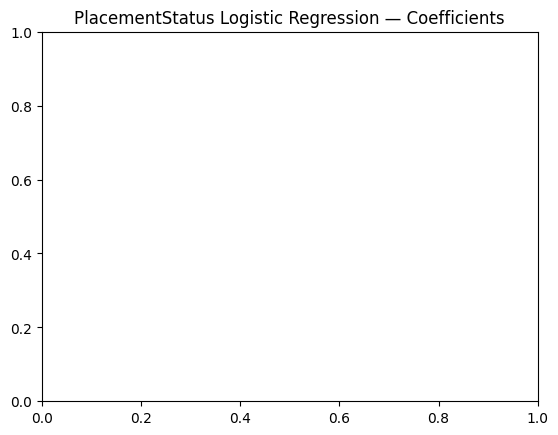

In [77]:
plt.title('PlacementStatus Logistic Regression — Coefficients')

In [78]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [79]:
plt.show()

In [80]:
numeric_cols_tier = [c for c in numeric_cols if c != 'CGPA']

In [81]:
X2 = df[numeric_cols_tier + categorical_cols]

In [82]:
y2 = df['CGPA_Tier']

In [83]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

In [84]:
preprocessor_tier = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols_tier),
    ('cat', categorical_transformer, categorical_cols)
])

In [85]:
tier_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tier),
    ('classifier', LogisticRegression(
        max_iter=2000, multi_class='multinomial', solver='lbfgs', random_state=42
    ))
])

In [86]:
tier_model.fit(X2_train, y2_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SGPA_Sem1', 'SGPA_Sem2',
                                                   'SGPA_Sem3', 'SGPA_Sem4',
                                                   'SGPA_Sem5', 'SGPA_Sem6',
                                                   'SGPA_Sem7', 'SGPA_Sem8',
                                                   'AttendancePercent',
                                                   'Internships', 'Projects',
                                                   'Workshops',
                                                   'Certifications',
                                                   'Publications',
                                                   'A...
                                                   'MockInterviewScore']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'City',
                                                   'CollegeTier', 'Stream',
                                                   'Specialisation', 'Hostel',
                                                   'HistoryOfBacklogs',
                                                   'ExtraCurricular'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, multi_class='multinomial',
                                    random_state=42))])

In [87]:
class_order = sorted(y2.unique())  # e.g. ['High','Low','Mid']

Accuracy : 0.9689
Precision: 0.9689
Recall   : 0.9689
F1-score : 0.9689


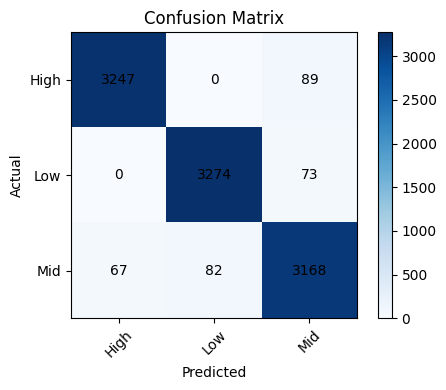


Classification Report:
               precision    recall  f1-score   support

        High       0.98      0.97      0.98      3336
         Low       0.98      0.98      0.98      3347
         Mid       0.95      0.96      0.95      3317

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [88]:
results_tier = evaluate_classifier(
    tier_model, X2_test, y2_test,
    class_names=class_order, average='macro'
)

In [89]:
feature_names_2 = get_feature_names(
    tier_model.named_steps['preprocessor'], numeric_cols_tier, categorical_cols
)

In [90]:
classes_2 = tier_model.named_steps['classifier'].classes_

In [91]:
coefs_2 = tier_model.named_steps['classifier'].coef_

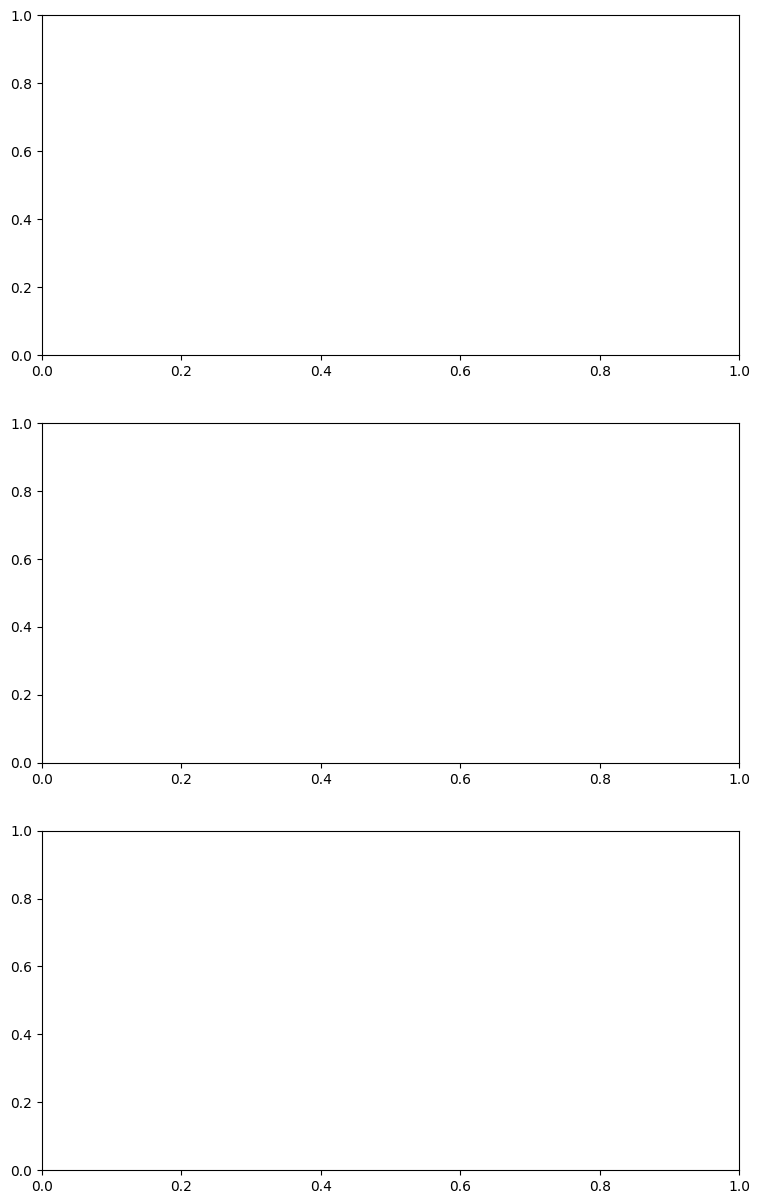

In [92]:
fig, axes = plt.subplots(len(classes_2), 1, figsize=(9, 5 * len(classes_2)))

In [93]:
if len(classes_2) == 1:
    axes = [axes]

In [94]:
for ax, cls, coef_row in zip(axes, classes_2, coefs_2):
    cdf = pd.DataFrame({'feature': feature_names_2, 'coefficient': coef_row})
    cdf = cdf.reindex(cdf.coefficient.abs().sort_values(ascending=False).index).head(15)
    colors = ['#2E7D32' if c > 0 else '#C62828' for c in cdf['coefficient']]
    ax.barh(cdf['feature'], cdf['coefficient'], color=colors)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'CGPA_Tier Logistic Regression — Class: {cls} (top 15)')
    ax.set_xlabel('Coefficient (log-odds impact)')

In [95]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [96]:
plt.show()

In [97]:
print("=== Model comparison ===")

=== Model comparison ===


In [98]:
print("PlacementStatus (binary):", results_placement)

PlacementStatus (binary): {'accuracy': 0.9201, 'precision': 0.9259149940968123, 'recall': 0.9548014000913103, 'f1': 0.9401363602307634}


In [99]:
print("CGPA_Tier (multinomial):", results_tier)

CGPA_Tier (multinomial): {'accuracy': 0.9689, 'precision': 0.9689000804738352, 'recall': 0.9688635525860202, 'f1': 0.9688764514569419}
